In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
import pandas as pd

df = pd.read_csv("../data/Reviews.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 568454
Columns: 10


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568438 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [4]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               16
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [5]:
def sentiment_label(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(sentiment_label)

df[["Score", "Sentiment"]].head()

,Score,Sentiment
0,5,Positive
1,1,Negative
2,4,Positive
3,2,Negative
4,5,Positive


In [6]:
df["Sentiment"].value_counts()

Positive    443777
Negative     82037
Neutral      42640
Name: Sentiment, dtype: int64

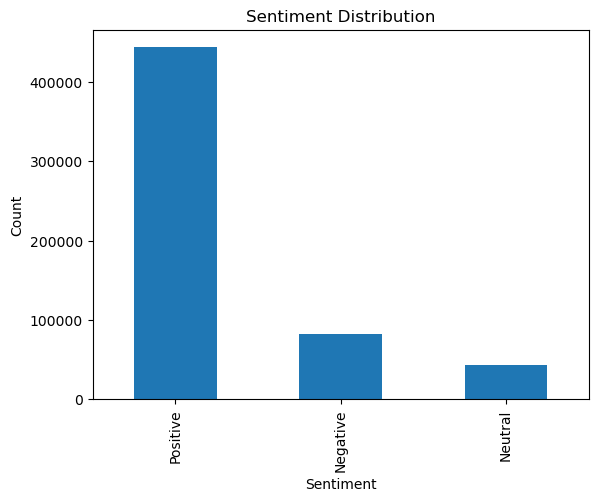

In [7]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [8]:
positive_reviews = df[df["Sentiment"]=="Positive"]

positive_reviews[["Score","Summary","Text"]].head(5)

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
4,5,Great taffy,Great taffy at a great price. There was a wid...
5,4,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,5,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...


In [9]:
negative_reviews = df[df["Sentiment"]=="Negative"]

negative_reviews[["Score","Summary","Text"]].head(5)

,Score,Summary,Text
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
12,1,My Cats Are Not Fans of the New Food,My cats have been happily eating Felidae Plati...
16,2,poor taste,I love eating them and they are good for watch...
26,1,Nasty No flavor,"The candy is just red , No flavor . Just plan..."


In [10]:
df["Review_Length"] = df["Text"].apply(len)

df["Review_Length"].describe()

count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: Review_Length, dtype: float64

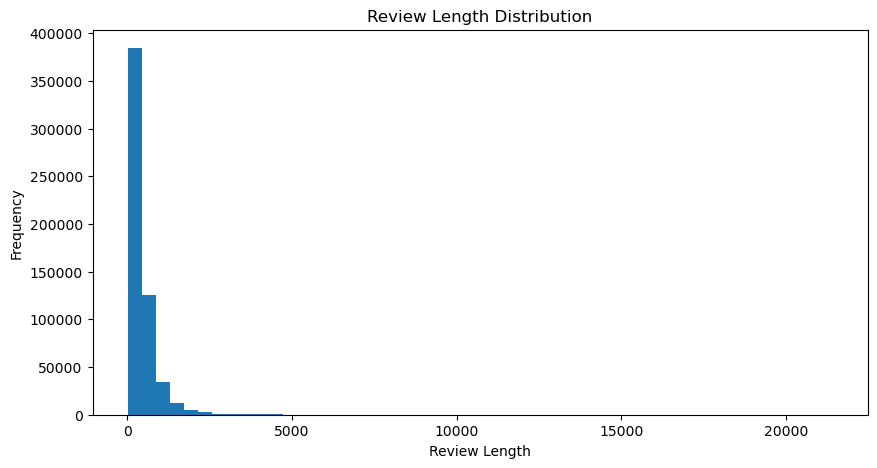

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["Review_Length"], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

In [16]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df["Clean_Text"] = df["Text"].apply(clean_text)

df[["Text","Clean_Text"]].head()

,Text,Clean_Text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...


In [17]:
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
def remove_stopwords(text):
    
    words = text.split()
    
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]
    
    return " ".join(filtered_words)

df["Processed_Text"] = df["Clean_Text"].apply(remove_stopwords)

df[["Clean_Text","Processed_Text"]].head()

,Clean_Text,Processed_Text
0,i have bought several of the vitality canned d...,bought several vitality canned dog food produc...
1,product arrived labeled as jumbo salted peanut...,product arrived labeled jumbo salted peanutsth...
2,this is a confection that has been around a fe...,confection around centuries light pillowy citr...
3,if you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,great taffy at a great price there was a wide ...,great taffy great price wide assortment yummy ...


In [18]:
print("Original Review:")
print(df["Text"].iloc[0])

print("\nProcessed Review:")
print(df["Processed_Text"].iloc[0])

Original Review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Processed Review:
bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better


In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["Processed_Text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

ModuleNotFoundError: No module named 'wordcloud'

In [21]:
!pip install wordcloud

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["Processed_Text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

KeyboardInterrupt: 

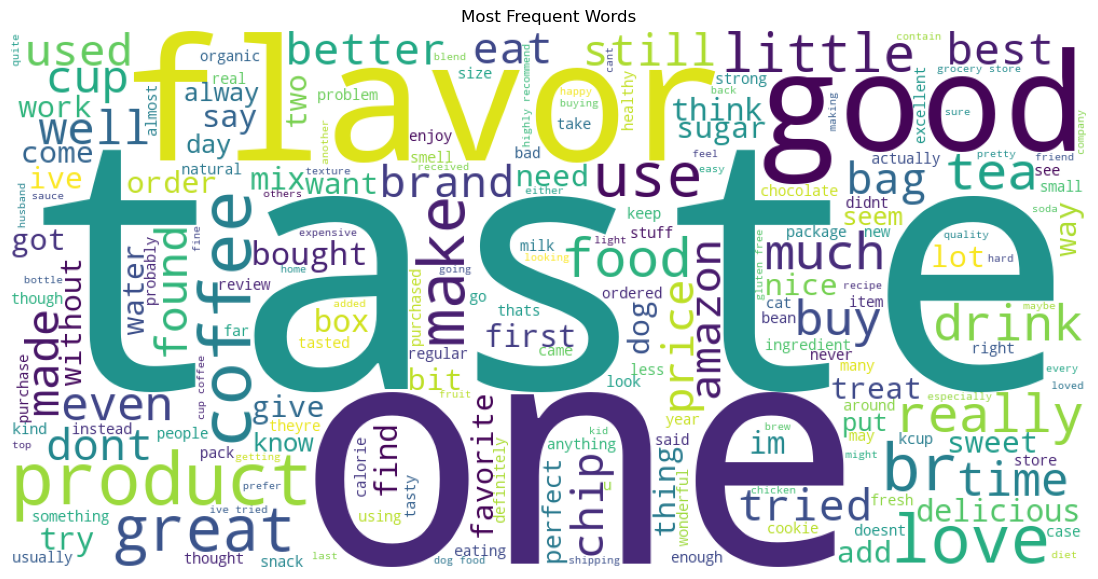

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sample_text = " ".join(df["Processed_Text"].head(10000))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(sample_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

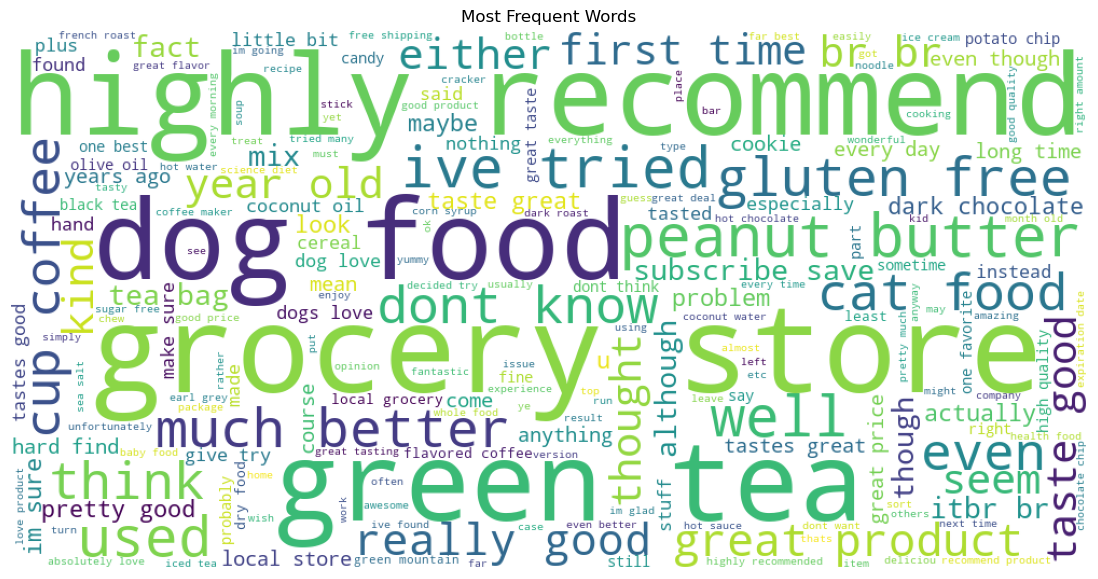

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["Processed_Text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Processed_Text"])

y = df["Sentiment"]

print(X.shape)

(568454, 5000)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(454763, 5000)
(113691, 5000)


In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8669991468102136


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.74      0.67      0.70     16181
     Neutral       0.51      0.19      0.27      8485
    Positive       0.90      0.97      0.93     89025

    accuracy                           0.87    113691
   macro avg       0.72      0.61      0.64    113691
weighted avg       0.85      0.87      0.85    113691



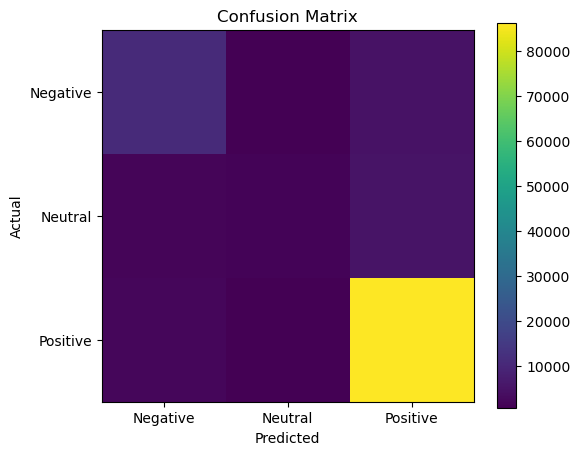

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)

plt.xticks([0,1,2],["Negative","Neutral","Positive"])
plt.yticks([0,1,2],["Negative","Neutral","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

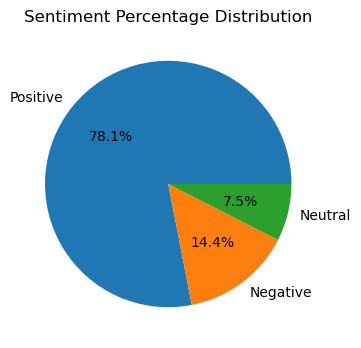

In [35]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))

sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Sentiment Percentage Distribution")

plt.show()